In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 데이터 샘플 체크

In [10]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv',delimiter = ',',skiprows=1)
data.shape

(100, 785)

5.0


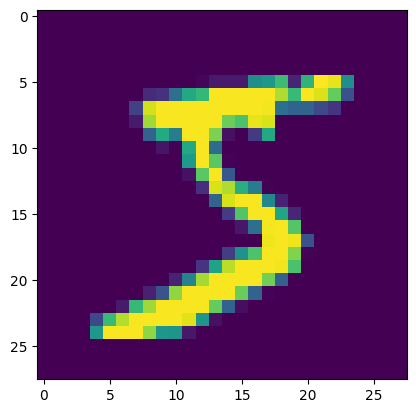

In [14]:
import matplotlib.pyplot as plt
print(data[0,0])
img = data[0,1:].reshape(28,28)
plt.imshow(img)

# 데이터 셋을 라이브러리에서 가져올 예정, 파일에서도 가져옴

In [105]:
import numpy as np
import pandas as pd # get_dummies
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.datasets import mnist # mnist 데이터 셋 => 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.layers import Dense, Input, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # 이미지 파일은 0 ~ 255의 값을 갖으므로 scaler 대신 값/255 사용
from sklearn.model_selection import train_test_split # 데이터 분리

In [7]:
data = np.loadtxt('data/mnist_train_small.csv',delimiter = ',',skiprows=1)
data.shape

(100, 785)

In [17]:
print('target :' ,data[1,0])
# print('imager(28*28 => dim=1) :' ,data[0,1:].reshape(28,28), sep='\n') # 5 확인 불가
# plt.imshow(data[0,1:].reshape(28,28))

target : 0.0


In [16]:
# 아래와 같은 for문 형태로 출력 가능
for row in data[1,1:].reshape(28,28) :
    for pixel in row :
        print('{:3.0f}'.format(pixel), end='')
    print('')

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51159253159 50  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 48238252252252237  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 54227253252239233252 57  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 10 60224252253252202 84252253122  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0163252252252253252252 96189253167  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 51238253253190114253228 47 79255168  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 48238252252179 12 75121 21  0  0253243 50  0  0  0  0  0
  0  0  0  0  0  0  0  0 38165253233208 84  0  0  0  0  0  025325

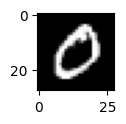

In [19]:
plt.figure(figsize=(1,1))
plt.imshow(data[1,1:].reshape(28,28), cmap='gray')

In [30]:
%pip install opencv-contrib-python
# ! pip show opencv-contrib-python

   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   -- ------------------------------------- 2.4/46.2 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/46.2 MB 11.9 MB/s eta 0:00:04
   ------ --------------------------------- 7.1/46.2 MB 11.8 MB/s eta 0:00:04
   -------- ------------------------------- 9.4/46.2 MB 11.5 MB/s eta 0:00:04
   ---------- ----------------------------- 12.1/46.2 MB 11.6 MB/s eta 0:00:03
   ------------ --------------------------- 14.4/46.2 MB 11.8 MB/s eta 0:00:03
   -------------- ------------------------- 16.8/46.2 MB 11.6 MB/s eta 0:00:03
   ---------------- ----------------------- 19.1/46.2 MB 11.7 MB/s eta 0:00:03
   ------------------ --------------------- 21.8/46.2 MB 11.7 MB/s eta 0:00:03
   -------------------- ------------------- 24.1/46.2 MB 11.7 MB/s eta 0:00:02
   ----------------------- ---------------- 26.7/46.2 MB 11.7 MB/s eta 0:00:02
   ------------------------- -------------- 29.1/46.2 MB 11.7 MB/

In [29]:
# %pip install opencv-python

In [35]:
# 칼라 사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('data/DNN_image.jpg',cv2.IMREAD_GRAYSCALE) # 흑백포멧으로 읽기
print(image_gray.shape)
print(type(image_gray))

(139, 364)
<class 'numpy.ndarray'>


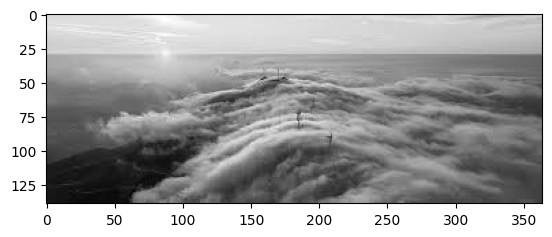

In [39]:
plt.imshow(image_gray, cmap='gray')

# 1. 데이터 생성 및 전처리

In [42]:
((X_train, y_train),(X_test, y_test)) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 67232 39  0  0  0  0  0
  0  0  0  0 62 81  0  0  0  0  0  0  0  0  0  0  0  0  0  0120180 39  0  0  0  0  0
  0  0  0  0126163  0  0  0  0  0  0  0  0  0  0  0  0  0  2153210 40  0  0  0  0  0
  0  0  0  0220163  0  0  0  0  0  0  0  0  0  0  0  0  0 27254162  0  0  0  0  0  0
  0  0  0  0222163  0  0  0  0  0  0  0  0  0  0  0  0  0183254125  0  0  0  0  0  0
  0  0  0 46245163  0  0  0  0  0  0  0  0  0  0  0  0  0198254 56  0  0  0  0  0  0
  0  0  0120254163  0  0  0  0  0  0  0  0  0  0  0  0 23231254 2

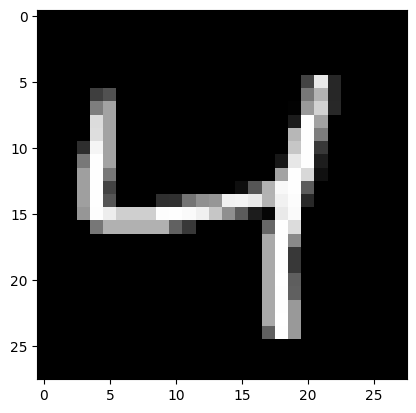

In [70]:
# 데이터 체크
for row in X_train[2] :
    for pixel in row :
        print(f'{pixel:3.0f}', end='')
    print('')
y_train[2]
plt.imshow(X_train[2], cmap='gray')

In [56]:
# 데이터셋 분할 : 학습셋(6만개) -> 훈련셋(5만개) + 검증셋(1만개)
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# X_val.shape, y_val.shape, X_train.shape, y_train.shape

((10000, 28, 28), (10000,), (50000, 28, 28), (50000,))

In [57]:
# 학습셋(5만개 : fit용), 검증셋(1만개, fit용), 시험용(1만개, evaluate용)
X_val.shape, y_val.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10000, 28, 28),
 (10000,),
 (50000, 28, 28),
 (50000,),
 (10000, 28, 28),
 (10000,))

In [60]:
# 입력(독립)변수 (28,28) -> n, 784 -> 실수형 변환 -> 스케일 조정(255.0으로 나눔)
train_X = (X_train.reshape(50000,-1).astype(np.float32))/255.0
val_X = (X_val.reshape(10000,-1).astype(np.float32))/255.0
test_X = (X_test.reshape(10000,-1).astype(np.float32))/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [65]:
# 학습시간을 줄이기 위해 아래와 같이 데이터 축소 : GPU가 없어서... accuract 저하 예상
# 훈련셋 : 50000개 중 700개, 검증셋 : 10000개 중 300개 추출, 테스트셋은 그대로
train_idx = np.random.choice(50000,700)
val_idx = np.random.choice(10000,300)

train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]

train_X.shape, y_train.shape, val_X.shape, y_val.shape

((700, 784), (700,), (300, 784), (300,))

In [69]:
# 타겟(종속)변수 원핫인코딩 -> 분류분석
train_Y = to_categorical(y_train)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((700, 10), (300, 10), (10000, 10))

# 2. 모델 생성 및 구성

In [75]:
model = Sequential()
model.add(Input(784,))
model.add(Dense(units=2, activation='relu'))
# model.add(Dense(units=, activation='relu'))
# model.add(Dense(units=, activation='relu'))
# model.add(Dense(units=, activation='relu'))
# model.add(Dense(units=, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 2)                 1570      
                                                                 
 dense_5 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 3. 모델 학습과정 설정

In [76]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics = ['accuracy'])

# 4. 모델 학습

In [77]:
%%time
hist = model.fit(train_X,train_Y, validation_data=(val_X, val_Y), epochs=500,batch_size=100)

Epoch 1/500
7/7 [==============================] - 1s 33ms/step - loss: 2.3155 - accuracy: 0.0643 - val_loss: 2.3108 - val_accuracy: 0.0633
Epoch 2/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2924 - accuracy: 0.0829 - val_loss: 2.3004 - val_accuracy: 0.0800
Epoch 3/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2749 - accuracy: 0.1114 - val_loss: 2.2810 - val_accuracy: 0.1133
Epoch 4/500
7/7 [==============================] - 0s 6ms/step - loss: 2.2437 - accuracy: 0.1371 - val_loss: 2.2567 - val_accuracy: 0.1167
Epoch 5/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2212 - accuracy: 0.1257 - val_loss: 2.2271 - val_accuracy: 0.1333
Epoch 6/500
7/7 [==============================] - 0s 7ms/step - loss: 2.1949 - accuracy: 0.1386 - val_loss: 2.1971 - val_accuracy: 0.1400
Epoch 7/500
7/7 [==============================] - 0s 7ms/step - loss: 2.1689 - accuracy: 0.1557 - val_loss: 2.1703 - val_accuracy: 0.2067
Epoch 8/500
7/7 [=========

7/7 [==============================] - 0s 8ms/step - loss: 1.5755 - accuracy: 0.4643 - val_loss: 1.6525 - val_accuracy: 0.4167
Epoch 60/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5681 - accuracy: 0.4657 - val_loss: 1.6469 - val_accuracy: 0.4200
Epoch 61/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5616 - accuracy: 0.4657 - val_loss: 1.6421 - val_accuracy: 0.4200
Epoch 62/500
7/7 [==============================] - 0s 6ms/step - loss: 1.5552 - accuracy: 0.4671 - val_loss: 1.6369 - val_accuracy: 0.4200
Epoch 63/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5484 - accuracy: 0.4700 - val_loss: 1.6331 - val_accuracy: 0.4200
Epoch 64/500
7/7 [==============================] - 0s 6ms/step - loss: 1.5425 - accuracy: 0.4714 - val_loss: 1.6288 - val_accuracy: 0.4233
Epoch 65/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5358 - accuracy: 0.4743 - val_loss: 1.6234 - val_accuracy: 0.4267
Epoch 66/500
7/7 [===============

7/7 [==============================] - 0s 7ms/step - loss: 1.3095 - accuracy: 0.5386 - val_loss: 1.4774 - val_accuracy: 0.4900
Epoch 118/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3059 - accuracy: 0.5457 - val_loss: 1.4768 - val_accuracy: 0.4833
Epoch 119/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3029 - accuracy: 0.5514 - val_loss: 1.4744 - val_accuracy: 0.4900
Epoch 120/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2996 - accuracy: 0.5486 - val_loss: 1.4726 - val_accuracy: 0.4900
Epoch 121/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2965 - accuracy: 0.5471 - val_loss: 1.4709 - val_accuracy: 0.4833
Epoch 122/500
7/7 [==============================] - 0s 8ms/step - loss: 1.2939 - accuracy: 0.5543 - val_loss: 1.4702 - val_accuracy: 0.4800
Epoch 123/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2905 - accuracy: 0.5514 - val_loss: 1.4679 - val_accuracy: 0.4867
Epoch 124/500
7/7 [========

7/7 [==============================] - 0s 8ms/step - loss: 1.1590 - accuracy: 0.5957 - val_loss: 1.4123 - val_accuracy: 0.5133
Epoch 176/500
7/7 [==============================] - 0s 8ms/step - loss: 1.1561 - accuracy: 0.6014 - val_loss: 1.4113 - val_accuracy: 0.5100
Epoch 177/500
7/7 [==============================] - 0s 8ms/step - loss: 1.1541 - accuracy: 0.5986 - val_loss: 1.4095 - val_accuracy: 0.5200
Epoch 178/500
7/7 [==============================] - 0s 7ms/step - loss: 1.1531 - accuracy: 0.6014 - val_loss: 1.4107 - val_accuracy: 0.5100
Epoch 179/500
7/7 [==============================] - 0s 6ms/step - loss: 1.1509 - accuracy: 0.5957 - val_loss: 1.4092 - val_accuracy: 0.5033
Epoch 180/500
7/7 [==============================] - 0s 8ms/step - loss: 1.1482 - accuracy: 0.5986 - val_loss: 1.4110 - val_accuracy: 0.5100
Epoch 181/500
7/7 [==============================] - 0s 8ms/step - loss: 1.1460 - accuracy: 0.6014 - val_loss: 1.4097 - val_accuracy: 0.5100
Epoch 182/500
7/7 [========

7/7 [==============================] - 0s 10ms/step - loss: 1.0556 - accuracy: 0.6286 - val_loss: 1.4011 - val_accuracy: 0.5100
Epoch 234/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0538 - accuracy: 0.6300 - val_loss: 1.3993 - val_accuracy: 0.5100
Epoch 235/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0525 - accuracy: 0.6271 - val_loss: 1.4008 - val_accuracy: 0.5033
Epoch 236/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0502 - accuracy: 0.6300 - val_loss: 1.4014 - val_accuracy: 0.5033
Epoch 237/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0488 - accuracy: 0.6286 - val_loss: 1.4003 - val_accuracy: 0.5100
Epoch 238/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0471 - accuracy: 0.6286 - val_loss: 1.4026 - val_accuracy: 0.5000
Epoch 239/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0456 - accuracy: 0.6314 - val_loss: 1.4038 - val_accuracy: 0.5033
Epoch 240/500
7/7 [=======

7/7 [==============================] - 0s 5ms/step - loss: 0.9760 - accuracy: 0.6557 - val_loss: 1.4232 - val_accuracy: 0.5067
Epoch 292/500
7/7 [==============================] - 0s 9ms/step - loss: 0.9748 - accuracy: 0.6586 - val_loss: 1.4271 - val_accuracy: 0.4967
Epoch 293/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9738 - accuracy: 0.6586 - val_loss: 1.4263 - val_accuracy: 0.5067
Epoch 294/500
7/7 [==============================] - 0s 5ms/step - loss: 0.9723 - accuracy: 0.6586 - val_loss: 1.4274 - val_accuracy: 0.5000
Epoch 295/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9711 - accuracy: 0.6571 - val_loss: 1.4275 - val_accuracy: 0.5000
Epoch 296/500
7/7 [==============================] - 0s 5ms/step - loss: 0.9703 - accuracy: 0.6614 - val_loss: 1.4276 - val_accuracy: 0.5067
Epoch 297/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9692 - accuracy: 0.6614 - val_loss: 1.4290 - val_accuracy: 0.5033
Epoch 298/500
7/7 [========

7/7 [==============================] - 0s 5ms/step - loss: 0.9163 - accuracy: 0.6700 - val_loss: 1.4664 - val_accuracy: 0.5067
Epoch 350/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9179 - accuracy: 0.6743 - val_loss: 1.4638 - val_accuracy: 0.5133
Epoch 351/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9131 - accuracy: 0.6771 - val_loss: 1.4743 - val_accuracy: 0.5133
Epoch 352/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9142 - accuracy: 0.6757 - val_loss: 1.4744 - val_accuracy: 0.5100
Epoch 353/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9120 - accuracy: 0.6743 - val_loss: 1.4691 - val_accuracy: 0.5100
Epoch 354/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9117 - accuracy: 0.6771 - val_loss: 1.4740 - val_accuracy: 0.5100
Epoch 355/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9109 - accuracy: 0.6714 - val_loss: 1.4775 - val_accuracy: 0.5133
Epoch 356/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 0.8656 - accuracy: 0.6929 - val_loss: 1.5308 - val_accuracy: 0.5100
Epoch 408/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8648 - accuracy: 0.6957 - val_loss: 1.5299 - val_accuracy: 0.5133
Epoch 409/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8643 - accuracy: 0.6943 - val_loss: 1.5345 - val_accuracy: 0.5167
Epoch 410/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8633 - accuracy: 0.6957 - val_loss: 1.5315 - val_accuracy: 0.5167
Epoch 411/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8627 - accuracy: 0.6971 - val_loss: 1.5356 - val_accuracy: 0.5133
Epoch 412/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8615 - accuracy: 0.6971 - val_loss: 1.5365 - val_accuracy: 0.5133
Epoch 413/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8617 - accuracy: 0.6971 - val_loss: 1.5407 - val_accuracy: 0.5200
Epoch 414/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 0.8237 - accuracy: 0.7114 - val_loss: 1.5965 - val_accuracy: 0.5233
Epoch 466/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8227 - accuracy: 0.7086 - val_loss: 1.6026 - val_accuracy: 0.5233
Epoch 467/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8220 - accuracy: 0.7071 - val_loss: 1.6012 - val_accuracy: 0.5267
Epoch 468/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8218 - accuracy: 0.7100 - val_loss: 1.5977 - val_accuracy: 0.5233
Epoch 469/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8210 - accuracy: 0.7100 - val_loss: 1.6044 - val_accuracy: 0.5267
Epoch 470/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8204 - accuracy: 0.7029 - val_loss: 1.6075 - val_accuracy: 0.5233
Epoch 471/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8198 - accuracy: 0.7071 - val_loss: 1.6044 - val_accuracy: 0.5233
Epoch 472/500
7/7 [========

# 5. 학습과정 살펴보기

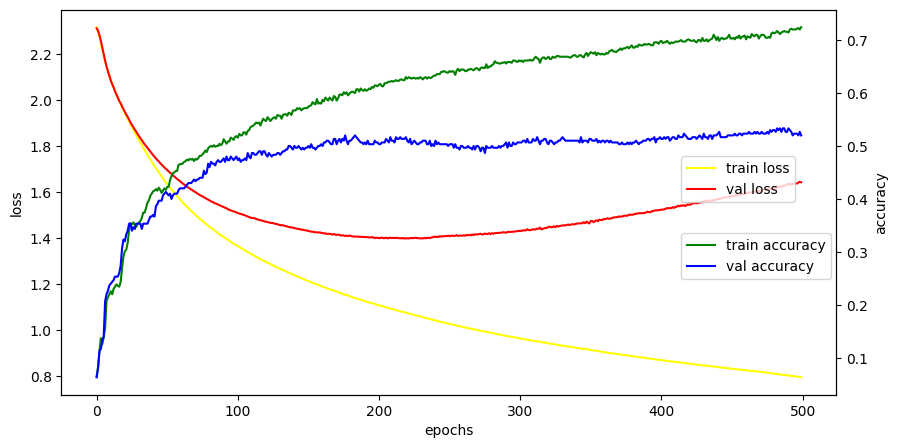

In [80]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(0.8,0.5))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(0.8,0.3))
acc_ax.set_ylabel('accuracy')
plt.show()

# 6. 모델 평가하기

In [82]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100)

100/100 [==============================] - 0s 2ms/step - loss: 1.7865 - accuracy: 0.5015


In [84]:
loss_and_metrics # loss = 1.786464810371399, metrics = 0.5015000104904175
print(f'loss : {loss_and_metrics[0]}')
print(f'accuracy : {loss_and_metrics[1]}')

loss : 1.786464810371399
accuracy : 0.5015000104904175


# 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정 : 레이어 추가/제거/units 조정 등
- 과적합 방지 : validiation data 추가, dropout, 활성화 함수(relu, tanh, elu, maxout....) 체크 -> 보통 relu 사용, 이미지는 tanh 사용
- epochs 조정
- optimizer 변경

Epoch 1/50
500/500 [==============================] - 22s 42ms/step - loss: 0.2634 - accuracy: 0.9183 - val_loss: 0.1258 - val_accuracy: 0.9615
Epoch 2/50
500/500 [==============================] - 20s 41ms/step - loss: 0.1475 - accuracy: 0.9555 - val_loss: 0.1012 - val_accuracy: 0.9693
Epoch 3/50
500/500 [==============================] - 20s 41ms/step - loss: 0.1141 - accuracy: 0.9646 - val_loss: 0.0954 - val_accuracy: 0.9715
Epoch 4/50
500/500 [==============================] - 23s 47ms/step - loss: 0.1009 - accuracy: 0.9687 - val_loss: 0.0918 - val_accuracy: 0.9740
Epoch 5/50
500/500 [==============================] - 23s 46ms/step - loss: 0.0913 - accuracy: 0.9714 - val_loss: 0.0968 - val_accuracy: 0.9742
Epoch 6/50
500/500 [==============================] - 24s 47ms/step - loss: 0.0811 - accuracy: 0.9749 - val_loss: 0.1002 - val_accuracy: 0.9733
Epoch 7/50
500/500 [==============================] - 23s 46ms/step - loss: 0.0787 - accuracy: 0.9751 - val_loss: 0.1055 - val_accuracy:

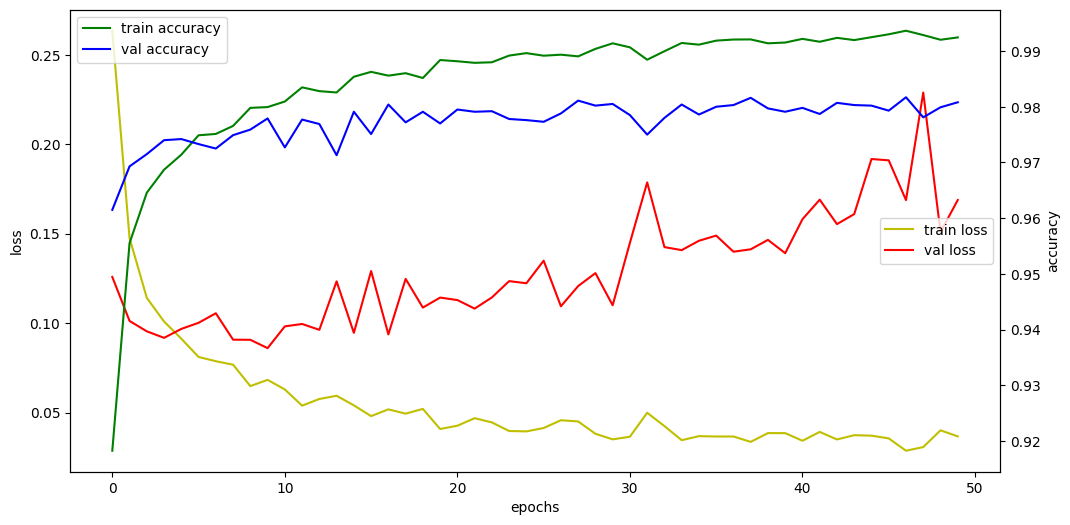

loss : 0.15588632225990295
accuracy : 0.9814000129699707
CPU times: total: 1h 42min 42s
Wall time: 18min 17s


In [103]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 샘플데이터 추출
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 1500)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
# model.add(Dense(units=1024, activation='tanh'))
# model.add(Dropout(0.1))
# model.add(Dense(units=2048, activation='relu')) # gelu, elu
# model.add(Dropout(0.49))
model.add(Dense(units=512, activation='relu'))
# from tensorflow.keras.layers import LeakyReLU
# model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units=10, activation='softmax'))
#모델 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 모델 학습
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y))
# 모델 학습과정 체크
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

In [110]:
# 모델 평가하기 / crosstab 그리기
y_test # == test_Y.argmax(axis=1)

313/313 [==============================] - 2s 7ms/step


In [112]:
y_hat = model.predict(test_X).argmax(axis=1)
y_hat

313/313 [==============================] - 3s 9ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [113]:
pd.crosstab(y_test,y_hat,rownames=['실제값'],colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,973,0,0,0,0,0,5,1,1,0
1,0,1129,1,0,1,0,1,1,2,0
2,2,1,1011,3,4,0,2,5,3,1
3,0,0,3,995,0,3,0,2,4,3
4,0,0,0,1,966,0,5,2,0,8
5,3,0,0,8,1,863,9,0,6,2
6,2,2,0,2,3,1,944,0,4,0
7,1,5,6,2,1,0,0,1007,2,4
8,4,0,1,6,1,3,1,4,951,3


In [116]:
# 틀린 개수 : 
len(y_test) - (loss_and_metrics[1] * len(y_test))

185.99987030029297

In [119]:
y_test[y_test!=y_hat].shape

(186,)

In [120]:
# 모델 저장
model.save('model/ch08_mnist.h5')

# ※ 콜백함수 1 : 로그출력

In [121]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [126]:
%%time
# 매 epoch마다 로그출력을 하면 지저분해 질 수 있으니 특정 epoch 마다 로그 출력하도록 제한
class CustomHistoy(Callback) :
    def __init__(self) : # 생성자 함수
        self.epoch=0
    def on_epoch_end(self, batch, logs={}): # 1 epoch마다 자동 실행되는 함수
        self.epoch +=1 # epoch마다 self.epoch값을 1씩 증가
        if self.epoch % 10 == 0 :
            print('epoch : {}, loss : {}, acc : {}, val_loss : {}, val_acc:{}'.format(self.epoch,logs.get('loss', '-'),logs.get('accuracy', '-'),
                                                                                     logs.get('val_loss', '-'),logs.get('val_accuracy', '-')))

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 샘플데이터 추출
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 1500)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
# model.add(Dense(units=1024, activation='tanh'))
# model.add(Dropout(0.1))
# model.add(Dense(units=2048, activation='relu')) # gelu, elu
# model.add(Dropout(0.49))
model.add(Dense(units=2, activation='relu'))
# from tensorflow.keras.layers import LeakyReLU
# model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units=10, activation='softmax'))
#모델 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 모델 학습
customHistoy = CustomHistoy()
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistoy])
# # 모델 학습과정 체크
# fig, loss_ax = plt.subplots(figsize=(12,6))
# loss_ax.plot(hist.history['loss'], 'y', label='train loss')
# loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
# acc_ax = loss_ax.twinx()
# acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
# acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
# loss_ax.set_xlabel('epochs')
# loss_ax.set_ylabel('loss')
# acc_ax.set_ylabel('accuracy')
# loss_ax.legend(loc='center right')
# acc_ax.legend()
# plt.show()

# loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
# print('loss :', loss_and_metrics[0])
# print('accuracy :', loss_and_metrics[1])

epoch : 10, loss : 1.8477405309677124, acc : 0.2865000069141388, val_loss : 1.861166000366211, val_acc:0.2879999876022339
epoch : 20, loss : 1.6304118633270264, acc : 0.4000000059604645, val_loss : 1.6628600358963013, val_acc:0.4059999883174896
epoch : 30, loss : 1.4955251216888428, acc : 0.4350000023841858, val_loss : 1.5473084449768066, val_acc:0.4320000112056732
epoch : 40, loss : 1.4107931852340698, acc : 0.45100000500679016, val_loss : 1.4770232439041138, val_acc:0.4506666660308838
epoch : 50, loss : 1.3495967388153076, acc : 0.45899999141693115, val_loss : 1.4329338073730469, val_acc:0.4566666781902313
CPU times: total: 8.59 s
Wall time: 6.96 s


# ※ 콜백함수 2 : EarlyStopping
- 기준을 정할 수 있음 / loss, accuracy
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 줄어들면 지정한 epoch를 다 수행하지 않고 조기 종료

In [130]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 샘플데이터 추출
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 1500)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
# model.add(Dense(units=1024, activation='tanh'))
# model.add(Dropout(0.1))
# model.add(Dense(units=2048, activation='relu')) # gelu, elu
# model.add(Dropout(0.49))
model.add(Dense(units=2, activation='relu'))
# from tensorflow.keras.layers import LeakyReLU
# model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units=10, activation='softmax'))
#모델 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 모델 학습
# monitor를 기준으로 patience번 이상 안좋은 데이터가 나오면 조기 종료
earlystopping = EarlyStopping(monitor = 'val_accuracy', patience=5,restore_best_weights=True) # 보통 val_loss, val_accuracy 순으로 많이 씀
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping])

Epoch 1/500
20/20 [==============================] - 1s 13ms/step - loss: 2.2895 - accuracy: 0.1645 - val_loss: 2.2709 - val_accuracy: 0.1860
Epoch 2/500
20/20 [==============================] - 0s 4ms/step - loss: 2.2437 - accuracy: 0.1420 - val_loss: 2.2195 - val_accuracy: 0.1320
Epoch 3/500
20/20 [==============================] - 0s 5ms/step - loss: 2.1903 - accuracy: 0.1395 - val_loss: 2.1775 - val_accuracy: 0.1313
Epoch 4/500
20/20 [==============================] - 0s 4ms/step - loss: 2.1560 - accuracy: 0.1905 - val_loss: 2.1497 - val_accuracy: 0.1920
Epoch 5/500
20/20 [==============================] - 0s 6ms/step - loss: 2.1310 - accuracy: 0.2055 - val_loss: 2.1294 - val_accuracy: 0.1980
Epoch 6/500
20/20 [==============================] - 0s 5ms/step - loss: 2.1118 - accuracy: 0.2135 - val_loss: 2.1124 - val_accuracy: 0.2100
Epoch 7/500
20/20 [==============================] - 0s 4ms/step - loss: 2.0948 - accuracy: 0.2165 - val_loss: 2.0984 - val_accuracy: 0.2087
Epoch 8/500


# ※ 콜백함수 3 : ModelCheckpoint
- epoch 마다 val_accuracy(val_loss, accuracy, loss) 값이 좋을 때 모델을 자동 저장하는 콜백

In [134]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 샘플데이터 추출
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 1500)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
# model.add(Dense(units=1024, activation='tanh'))
# model.add(Dropout(0.1))
# model.add(Dense(units=2048, activation='relu')) # gelu, elu
# model.add(Dropout(0.49))
model.add(Dense(units=2, activation='relu'))
# from tensorflow.keras.layers import LeakyReLU
# model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units=10, activation='softmax'))
#모델 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 모델 학습
# monitor를 기준으로 patience번 이상 안좋은 데이터가 나오면 조기 종료
earlystopping = EarlyStopping(monitor = 'val_loss', patience=10, # 보통 val_loss, val_accuracy 순으로 많이 씀
                              #restore_best_weights=True 훈련 종료 시 가장 성능이 좋은 가중치 복원
                             ) 
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder) : # 폴더가 경로에 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5' # f스트링 작동 안함

checkpoint = ModelCheckpoint(filepath=file, # 저장경로
                             monitor = 'val_accuracy', # 모니터할 지표
                             save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                             mode = 'max', # 값이 클수록 저장 -> 기본값 auto라서 건드리지 않아도...
                             verbose = 1, # 저장 시 로그 출력
                            )

hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint])

Epoch 1/500
 1/20 [>.............................] - ETA: 6s - loss: 2.3457 - accuracy: 0.0900
Epoch 1: val_accuracy improved from -inf to 0.12333, saving model to ./model08\mnist-001-val0.1233.h5
20/20 [==============================] - 1s 13ms/step - loss: 2.2895 - accuracy: 0.1045 - val_loss: 2.2528 - val_accuracy: 0.1233
Epoch 2/500
 1/20 [>.............................] - ETA: 0s - loss: 2.2627 - accuracy: 0.1100
Epoch 2: val_accuracy did not improve from 0.12333
20/20 [==============================] - 0s 5ms/step - loss: 2.2179 - accuracy: 0.1090 - val_loss: 2.1718 - val_accuracy: 0.1047
Epoch 3/500
 1/20 [>.............................] - ETA: 0s - loss: 2.1762 - accuracy: 0.1100
Epoch 3: val_accuracy improved from 0.12333 to 0.13267, saving model to ./model08\mnist-003-val0.1327.h5
20/20 [==============================] - 0s 5ms/step - loss: 2.1487 - accuracy: 0.1140 - val_loss: 2.1081 - val_accuracy: 0.1327
Epoch 4/500
 1/20 [>.............................] - ETA: 0s - loss: 

Epoch 26/500
 1/20 [>.............................] - ETA: 0s - loss: 1.6157 - accuracy: 0.3500
Epoch 26: val_accuracy improved from 0.40267 to 0.40467, saving model to ./model08\mnist-026-val0.4047.h5
20/20 [==============================] - 0s 5ms/step - loss: 1.6076 - accuracy: 0.4150 - val_loss: 1.6135 - val_accuracy: 0.4047
Epoch 27/500
 1/20 [>.............................] - ETA: 0s - loss: 1.6092 - accuracy: 0.4000
Epoch 27: val_accuracy improved from 0.40467 to 0.41467, saving model to ./model08\mnist-027-val0.4147.h5
20/20 [==============================] - 0s 5ms/step - loss: 1.5962 - accuracy: 0.4230 - val_loss: 1.6047 - val_accuracy: 0.4147
Epoch 28/500
 1/20 [>.............................] - ETA: 0s - loss: 1.6666 - accuracy: 0.4300
Epoch 28: val_accuracy improved from 0.41467 to 0.42800, saving model to ./model08\mnist-028-val0.4280.h5
20/20 [==============================] - 0s 6ms/step - loss: 1.5865 - accuracy: 0.4345 - val_loss: 1.5977 - val_accuracy: 0.4280
Epoch 2

Epoch 52/500
 1/20 [>.............................] - ETA: 0s - loss: 1.4086 - accuracy: 0.6300
Epoch 52: val_accuracy improved from 0.51333 to 0.51400, saving model to ./model08\mnist-052-val0.5140.h5
20/20 [==============================] - 0s 5ms/step - loss: 1.4179 - accuracy: 0.5330 - val_loss: 1.4675 - val_accuracy: 0.5140
Epoch 53/500
 1/20 [>.............................] - ETA: 0s - loss: 1.3251 - accuracy: 0.4700
Epoch 53: val_accuracy did not improve from 0.51400
20/20 [==============================] - 0s 4ms/step - loss: 1.4132 - accuracy: 0.5405 - val_loss: 1.4639 - val_accuracy: 0.5113
Epoch 54/500
 1/20 [>.............................] - ETA: 0s - loss: 1.4269 - accuracy: 0.5300
Epoch 54: val_accuracy improved from 0.51400 to 0.51467, saving model to ./model08\mnist-054-val0.5147.h5
20/20 [==============================] - 0s 5ms/step - loss: 1.4080 - accuracy: 0.5350 - val_loss: 1.4630 - val_accuracy: 0.5147
Epoch 55/500
 1/20 [>.............................] - ETA: 0s

Epoch 80/500
 1/20 [>.............................] - ETA: 0s - loss: 1.2387 - accuracy: 0.5900
Epoch 80: val_accuracy did not improve from 0.54667
20/20 [==============================] - 0s 4ms/step - loss: 1.2852 - accuracy: 0.5655 - val_loss: 1.3832 - val_accuracy: 0.5467
Epoch 81/500
 1/20 [>.............................] - ETA: 0s - loss: 1.2060 - accuracy: 0.6300
Epoch 81: val_accuracy did not improve from 0.54667
20/20 [==============================] - 0s 4ms/step - loss: 1.2816 - accuracy: 0.5675 - val_loss: 1.3805 - val_accuracy: 0.5427
Epoch 82/500
 1/20 [>.............................] - ETA: 0s - loss: 1.3115 - accuracy: 0.5300
Epoch 82: val_accuracy did not improve from 0.54667
20/20 [==============================] - 0s 4ms/step - loss: 1.2784 - accuracy: 0.5705 - val_loss: 1.3806 - val_accuracy: 0.5373
Epoch 83/500
 1/20 [>.............................] - ETA: 0s - loss: 1.2401 - accuracy: 0.5300
Epoch 83: val_accuracy improved from 0.54667 to 0.54733, saving model to 

 1/20 [>.............................] - ETA: 0s - loss: 1.2113 - accuracy: 0.6100
Epoch 109: val_accuracy did not improve from 0.54733
20/20 [==============================] - 0s 5ms/step - loss: 1.2037 - accuracy: 0.5830 - val_loss: 1.3490 - val_accuracy: 0.5373
Epoch 110/500
 1/20 [>.............................] - ETA: 0s - loss: 1.2360 - accuracy: 0.5400
Epoch 110: val_accuracy did not improve from 0.54733
20/20 [==============================] - 0s 5ms/step - loss: 1.2021 - accuracy: 0.5875 - val_loss: 1.3496 - val_accuracy: 0.5440
Epoch 111/500
 1/20 [>.............................] - ETA: 0s - loss: 1.1636 - accuracy: 0.5700
Epoch 111: val_accuracy did not improve from 0.54733
20/20 [==============================] - 0s 4ms/step - loss: 1.1988 - accuracy: 0.5845 - val_loss: 1.3485 - val_accuracy: 0.5387
Epoch 112/500
 1/20 [>.............................] - ETA: 0s - loss: 1.1206 - accuracy: 0.6000
Epoch 112: val_accuracy did not improve from 0.54733
20/20 [====================

20/20 [==============================] - 0s 4ms/step - loss: 1.1495 - accuracy: 0.5935 - val_loss: 1.3388 - val_accuracy: 0.5433
Epoch 139/500
 1/20 [>.............................] - ETA: 0s - loss: 1.2882 - accuracy: 0.5400
Epoch 139: val_accuracy did not improve from 0.54733
20/20 [==============================] - 0s 4ms/step - loss: 1.1479 - accuracy: 0.5900 - val_loss: 1.3434 - val_accuracy: 0.5347
Epoch 140/500
 1/20 [>.............................] - ETA: 0s - loss: 1.2188 - accuracy: 0.5800
Epoch 140: val_accuracy did not improve from 0.54733
20/20 [==============================] - 0s 5ms/step - loss: 1.1460 - accuracy: 0.5985 - val_loss: 1.3395 - val_accuracy: 0.5427
Epoch 141/500
 1/20 [>.............................] - ETA: 0s - loss: 1.1459 - accuracy: 0.5200
Epoch 141: val_accuracy did not improve from 0.54733
20/20 [==============================] - 0s 4ms/step - loss: 1.1456 - accuracy: 0.5965 - val_loss: 1.3390 - val_accuracy: 0.5440
Epoch 142/500
 1/20 [>............